In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

DB_USER     = "root"
DB_PASSWORD = "1234"    
DB_HOST     = "localhost"
DB_PORT     = 3306
DB_NAME     = "cricket_db"

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print("✓ Connected to MySQL:", DB_NAME)

✓ Connected to MySQL: cricket_db


In [7]:
kpi = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM matches)        AS total_matches,
        (SELECT COUNT(*) FROM deliveries)     AS total_deliveries,
        (SELECT SUM(runs_batter) FROM deliveries) AS total_runs,
        (SELECT SUM(is_wicket)  FROM deliveries)  AS total_wickets,
        (SELECT COUNT(CASE WHEN runs_batter=6 THEN 1 END) FROM deliveries) AS total_sixes,
        (SELECT COUNT(*) FROM players)        AS total_players,
        (SELECT COUNT(*) FROM teams)          AS total_teams
""", engine).iloc[0]

print("=" * 50)
print(f"  Total Matches    : {int(kpi.total_matches):>10,}")
print(f"  Total Deliveries : {int(kpi.total_deliveries):>10,}")
print(f"  Total Runs       : {int(kpi.total_runs):>10,}")
print(f"  Total Wickets    : {int(kpi.total_wickets):>10,}")
print(f"  Total Sixes      : {int(kpi.total_sixes):>10,}")
print(f"  Players          : {int(kpi.total_players):>10,}")
print(f"  Teams            : {int(kpi.total_teams):>10,}")
print("=" * 50)

  Total Matches    :      9,813
  Total Deliveries :  4,508,144
  Total Runs       :  3,696,330
  Total Wickets    :    145,313
  Total Sixes      :     94,825
  Players          :      6,029
  Teams            :        192


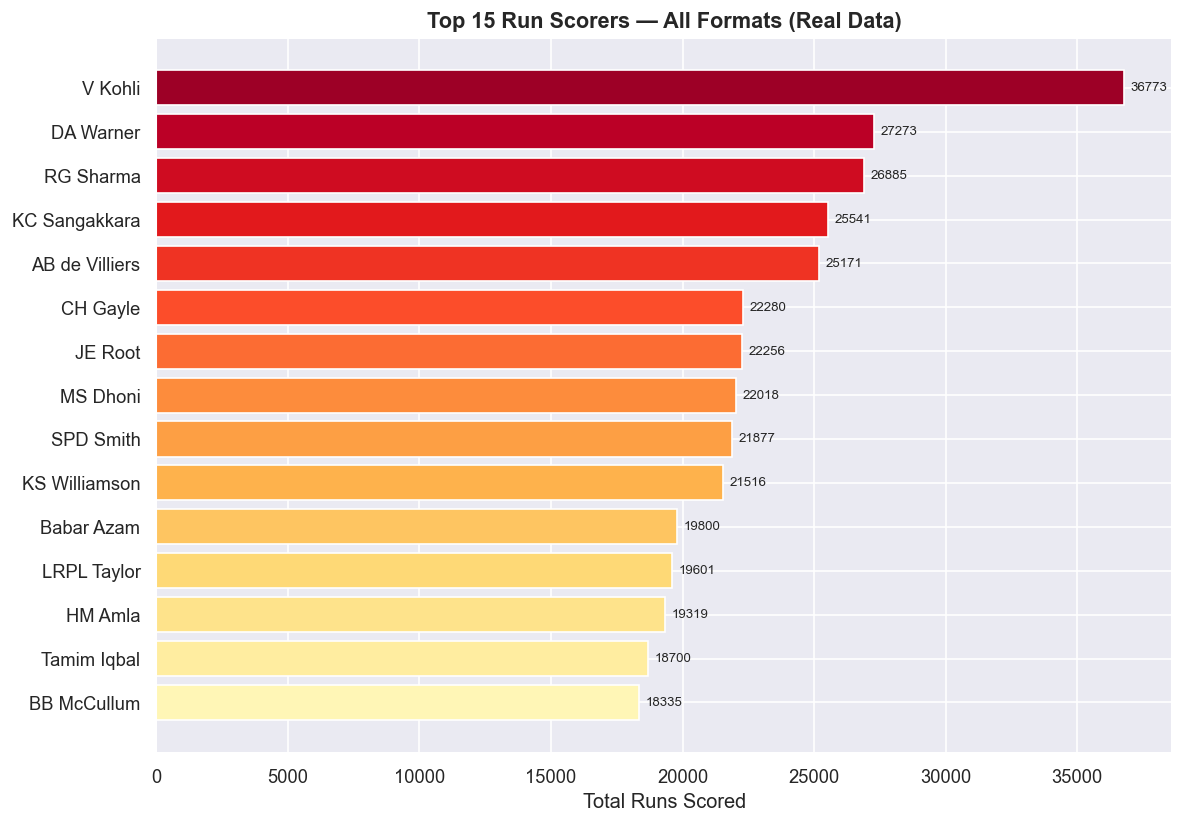

✓ Saved chart_top_batsmen.png


In [9]:
top_bat = pd.read_sql("""
    SELECT p.player_name, SUM(d.runs_batter) AS total_runs,
           COUNT(DISTINCT d.match_id) AS matches
    FROM deliveries d JOIN players p ON d.batter_id = p.player_id
    GROUP BY p.player_name
    ORDER BY total_runs DESC LIMIT 15
""", engine)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("YlOrRd", 15)[::-1]
bars = ax.barh(top_bat["player_name"], top_bat["total_runs"], color=colors)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=8)
ax.set_xlabel("Total Runs Scored"); ax.invert_yaxis()
ax.set_title("Top 15 Run Scorers — All Formats (Real Data)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_top_batsmen.png", dpi=120); plt.show()
print("✓ Saved chart_top_batsmen.png")


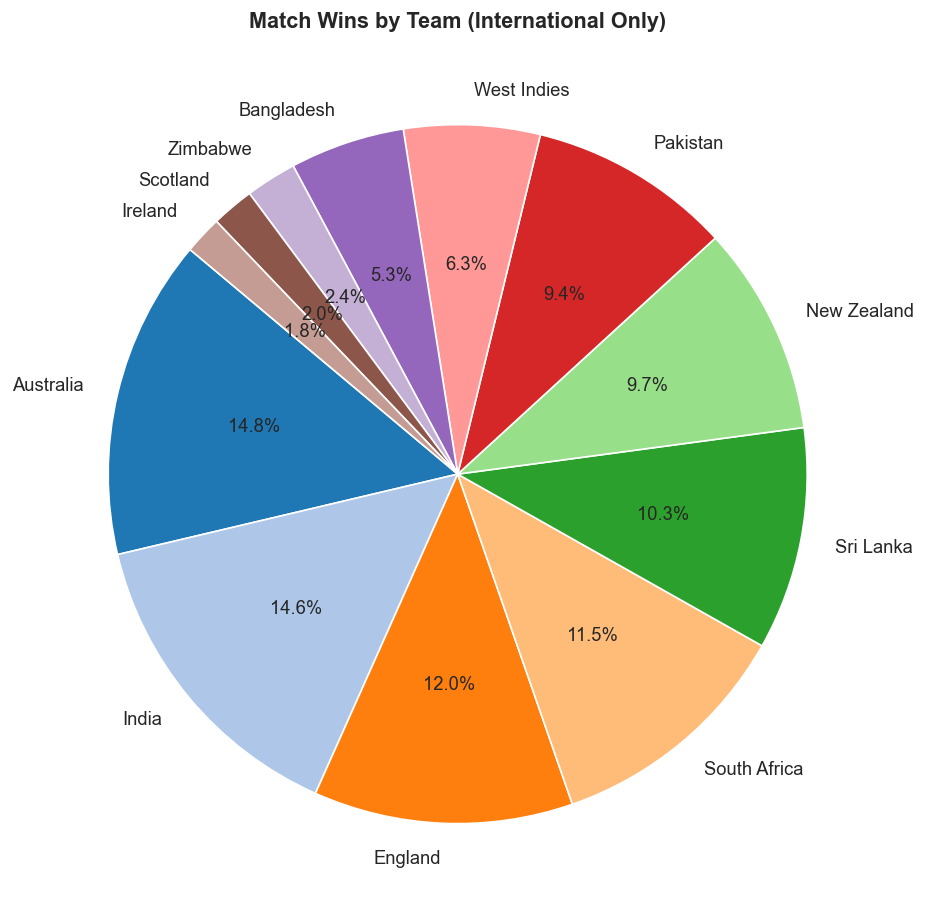

✓ Saved chart_team_wins_pie.png


In [27]:
win_df = pd.read_sql("""
    SELECT t.team_name, COUNT(*) AS wins
    FROM matches m 
    JOIN teams t ON m.winner_id = t.team_id
    WHERE m.match_type IN ('ODI', 'T20I', 'Test')
    GROUP BY t.team_name 
    ORDER BY wins DESC 
    LIMIT 12
""", engine)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    win_df["wins"],
    labels=win_df["team_name"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("tab20", len(win_df))
)

ax.set_title(
    "Match Wins by Team (International Only)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("chart_team_wins_pie.png", dpi=120)
plt.show()

print("✓ Saved chart_team_wins_pie.png")

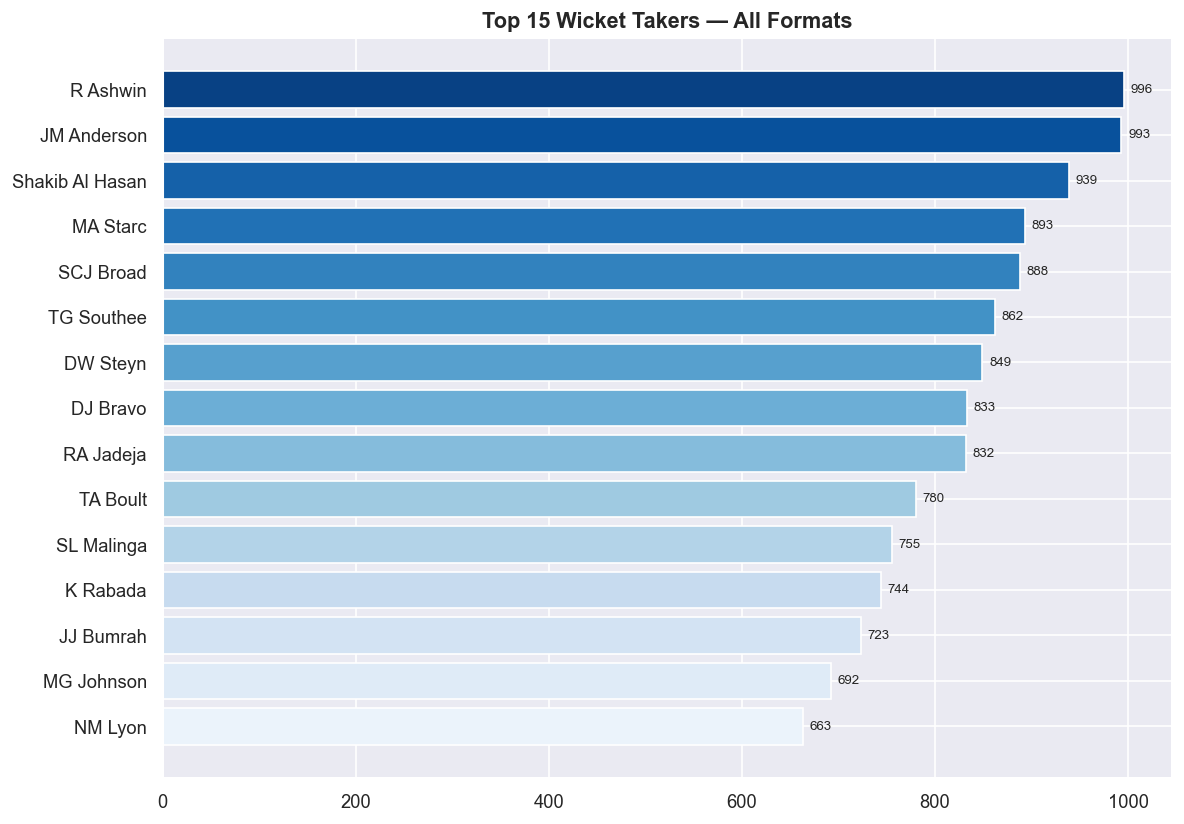

✓ Saved chart_top_bowlers.png


In [15]:
bowl_df = pd.read_sql("""
    SELECT p.player_name, SUM(d.is_wicket) AS total_wickets,
           ROUND(SUM(d.runs_total)/NULLIF(COUNT(CASE WHEN d.wides=0 AND d.no_balls=0 THEN 1 END),0)*6,2) AS economy
    FROM deliveries d JOIN players p ON d.bowler_id = p.player_id
    GROUP BY p.player_name HAVING total_wickets >= 10
    ORDER BY total_wickets DESC LIMIT 15
""", engine)

fig, ax = plt.subplots(figsize=(10, 7))
bars2 = ax.barh(bowl_df["player_name"], bowl_df["total_wickets"],
                color=sns.color_palette("Blues_r", 15))
ax.bar_label(bars2, fmt="%d", padding=4, fontsize=8)
ax.invert_yaxis()
ax.set_title("Top 15 Wicket Takers — All Formats", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_top_bowlers.png", dpi=120); plt.show()
print("✓ Saved chart_top_bowlers.png")


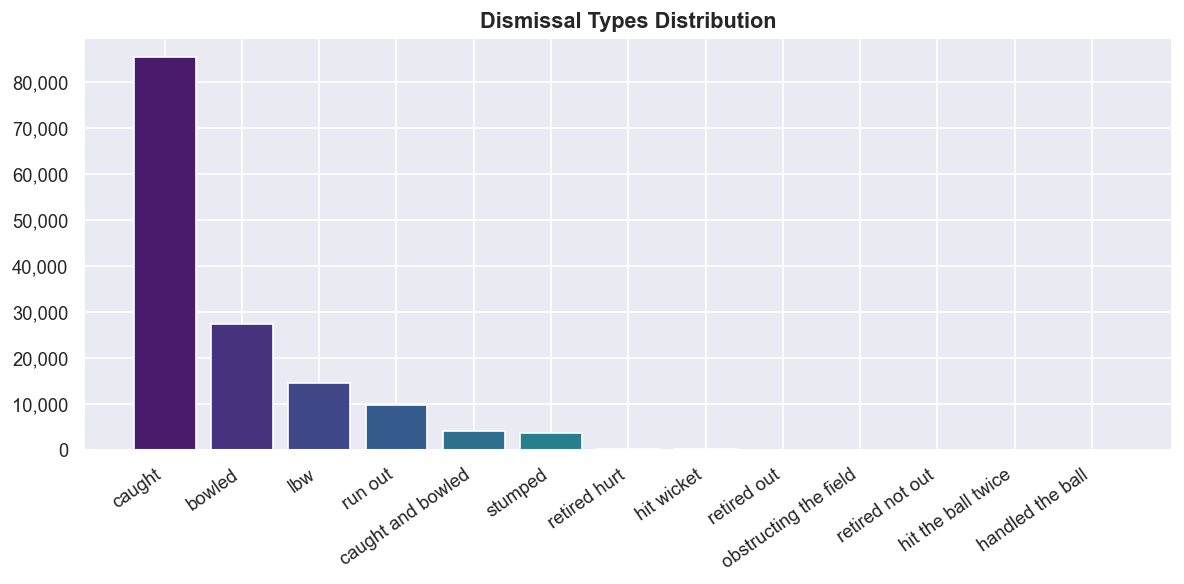

✓ Saved chart_dismissal_types.png


In [17]:
wkt_df = pd.read_sql("""
    SELECT wicket_kind, COUNT(*) AS dismissals
    FROM deliveries WHERE is_wicket=1 AND wicket_kind IS NOT NULL
    GROUP BY wicket_kind ORDER BY dismissals DESC
""", engine)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(wkt_df["wicket_kind"], wkt_df["dismissals"],
       color=sns.color_palette("viridis", len(wkt_df)))
plt.xticks(rotation=35, ha="right")
ax.set_title("Dismissal Types Distribution", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("chart_dismissal_types.png", dpi=120); plt.show()
print("✓ Saved chart_dismissal_types.png")

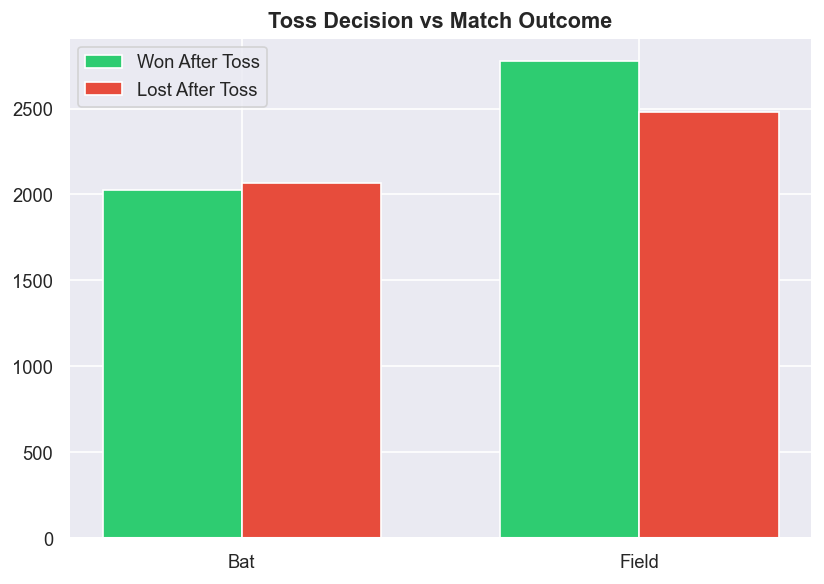

✓ Saved chart_toss_impact.png


In [19]:
toss_df = pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total,
           SUM(CASE WHEN toss_winner_id=winner_id THEN 1 ELSE 0 END) AS toss_won
    FROM matches WHERE result_type IN ('runs','wickets','innings')
    GROUP BY toss_decision
""", engine)
toss_df["toss_lost"] = toss_df["total"] - toss_df["toss_won"]

x = np.arange(len(toss_df)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x-w/2, toss_df["toss_won"],  w, label="Won After Toss",  color="#2ecc71")
ax.bar(x+w/2, toss_df["toss_lost"], w, label="Lost After Toss", color="#e74c3c")
ax.set_xticks(x); ax.set_xticklabels(toss_df["toss_decision"].str.capitalize())
ax.set_title("Toss Decision vs Match Outcome", fontsize=13, fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("chart_toss_impact.png", dpi=120); plt.show()
print("✓ Saved chart_toss_impact.png")

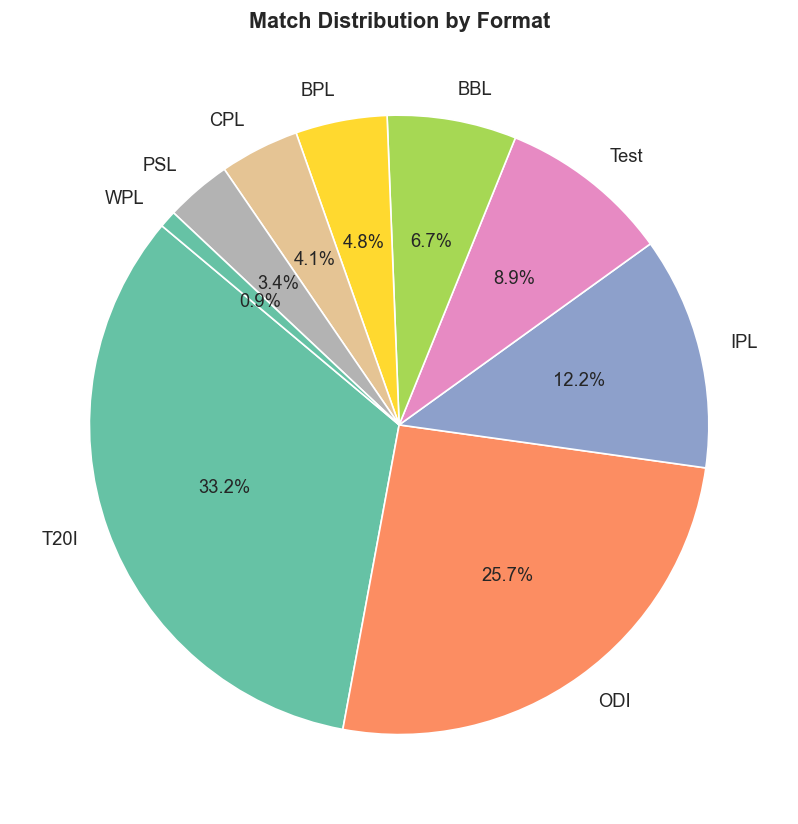

✓ Saved chart_format_dist.png

 All 7 charts saved. Open the PNG files to view them.
   Next: run 'streamlit run dashboard/dashboard.py'


In [29]:
fmt_df = pd.read_sql("""
    SELECT format_label, COUNT(*) AS matches
    FROM matches GROUP BY format_label ORDER BY matches DESC
""", engine)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(fmt_df["matches"], labels=fmt_df["format_label"], autopct="%1.1f%%",
       startangle=140, colors=sns.color_palette("Set2", len(fmt_df)))
ax.set_title("Match Distribution by Format", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_format_dist.png", dpi=120); plt.show()
print("✓ Saved chart_format_dist.png")


print("\n All 7 charts saved. Open the PNG files to view them.")
print("   Next: run 'streamlit run dashboard/dashboard.py'")